In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

path = kagglehub.dataset_download("laotse/credit-risk-dataset")

csv_filename = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_filename)
# csv_path = "data/credit_risk_dataset.csv"

df = pd.read_csv(csv_path)
print(df.shape)
df.head()
from optbinning import BinningProcess, OptimalBinning

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

(32581, 12)


In [14]:
# nulos
print(df.isnull().sum()[df.isnull().sum() > 0])

# como viene el target. 1 = moroso
default_dist = df['loan_status'].value_counts(normalize=True) * 100
print(default_dist.round(2).astype(str) + '%')

person_emp_length     895
loan_int_rate        3116
dtype: int64
loan_status
0    78.18%
1    21.82%
Name: proportion, dtype: str


In [15]:
target_col = 'loan_status'

X = df.drop(columns=[target_col])
y = df[target_col]

# optbinning necesita que le pase cuales son categoricas
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(len(categorical_cols), categorical_cols)
print(len(numerical_cols), numerical_cols)

4 ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
7 ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


C:\Users\elgra\AppData\Local\Temp\ipykernel_23140\1149919437.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [16]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [17]:
from optbinning import BinningProcess

# esto lo tenia con X entero y estaba mal: los cortes del binning veian el
# target del test y el gini me daba mas alto de lo que era. va solo con train
binning_process = BinningProcess(
    variable_names=list(X.columns),
    categorical_variables=categorical_cols
)

binning_process.fit(X_train_raw, y_train)

iv_summary = (
    binning_process.summary()
    .sort_values(by="iv", ascending=False)
)

iv_summary

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
8,loan_percent_income,numerical,OPTIMAL,True,10,0.953721,0.10436,0.443709,0.01644
5,loan_grade,categorical,OPTIMAL,True,4,0.834618,0.095384,0.436406,0.327661
7,loan_int_rate,numerical,OPTIMAL,True,11,0.670894,0.077495,0.416108,0.136849
1,person_income,numerical,OPTIMAL,True,7,0.57637,0.067146,0.396509,0.744881
2,person_home_ownership,categorical,OPTIMAL,True,3,0.386377,0.047055,0.303412,0.706839
9,cb_person_default_on_file,categorical,OPTIMAL,True,2,0.159914,0.019608,0.163495,0.239037
6,loan_amnt,numerical,OPTIMAL,True,10,0.095098,0.011729,0.161858,0.113002
4,loan_intent,categorical,OPTIMAL,True,6,0.088282,0.010977,0.162626,0.134675
3,person_emp_length,numerical,OPTIMAL,True,8,0.066238,0.008242,0.142946,0.003919
0,person_age,numerical,OPTIMAL,True,7,0.010358,0.001293,0.05022,0.001924


In [18]:
# el scorecard despues quiere raw, la logistica quiere woe
X_train_woe = binning_process.transform(X_train_raw, metric="woe")
X_test_woe = binning_process.transform(X_test_raw, metric="woe")

In [19]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model = LogisticRegression(random_state=42)
# si tira el warning de convergencia, subir max_iter
model.fit(X_train_woe, y_train)

y_pred_proba_test = model.predict_proba(X_test_woe)[:, 1]

auc_test = roc_auc_score(y_test, y_pred_proba_test)
gini_test = 2 * auc_test - 1
print(f"Gini Test: {gini_test:.4f}")

Gini Test: 0.7730


In [20]:
# esta es la de mayor IV, miro como quedaron los cortes
optb = binning_process.get_binned_variable("loan_percent_income")
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.05)",2433,0.106682,2193,240,0.098644,0.935874,0.069954,0.008438
1,"[0.05, 0.07)",1859,0.081514,1636,223,0.119957,0.716325,0.033614,0.004114
2,"[0.07, 0.13)",5940,0.260458,5193,747,0.125758,0.662489,0.093466,0.011474
3,"[0.13, 0.16)",1758,0.077085,1515,243,0.138225,0.553596,0.019996,0.002468
4,"[0.16, 0.18)",1698,0.074454,1396,302,0.177856,0.254426,0.004475,0.000558
5,"[0.18, 0.21)",2728,0.119618,2218,510,0.186950,0.193437,0.004232,0.000528
6,"[0.21, 0.25)",2019,0.088529,1630,389,0.192670,0.156243,0.002066,0.000258
7,"[0.25, 0.31)",1685,0.073884,1257,428,0.254006,-0.199153,0.003094,0.000386
8,"[0.31, 0.36)",1164,0.051039,367,797,0.684708,-2.052006,0.286499,0.030612
9,"[0.36, inf)",1522,0.066737,426,1096,0.720105,-2.221496,0.436325,0.045523


In [21]:
from scipy.stats import ks_2samp

good_probs = y_pred_proba_test[y_test == 0]
bad_probs = y_pred_proba_test[y_test == 1]

ks_stat, p_value = ks_2samp(good_probs, bad_probs)

print(f"Estadístico KS (Test): {ks_stat * 100:.2f}%")

Estadístico KS (Test): 64.50%


In [22]:
from optbinning import Scorecard

scorecard = Scorecard(
    binning_process=binning_process,
    estimator=model,
    scaling_method="min_max",
    scaling_method_params={"min": 300, "max": 850}
)

# tener en cuenta: raw, no woe. la primera vez le pase el woe y salia cualquier cosa
scorecard.fit(X_train_raw, y_train)

scorecard_table = scorecard.table(style="summary")
scorecard_table

,Variable,Bin,Points
0,person_age,"(-inf, 22.50)",55.959988
1,person_age,"[22.50, 25.50)",56.272231
2,person_age,"[25.50, 28.50)",56.305943
3,person_age,"[28.50, 31.50)",56.396306
4,person_age,"[31.50, 34.50)",56.476629
...,...,...,...
4,cb_person_cred_hist_length,"[6.50, 7.50)",60.085631
5,cb_person_cred_hist_length,"[7.50, 13.50)",56.963004
6,cb_person_cred_hist_length,"[13.50, inf)",56.309107
7,cb_person_cred_hist_length,Special,56.265472


In [23]:
df_resultado = df.copy()
df_resultado['Score'] = scorecard.score(X).round().astype(int)

df_resultado[['person_age', 'person_income', 'loan_intent', 'loan_amnt', 'Score', 'loan_status']].head(10)

,person_age,person_income,loan_intent,loan_amnt,Score,loan_status
0,22,59000,PERSONAL,35000,411,1
1,21,9600,EDUCATION,1000,664,0
2,25,9600,MEDICAL,5500,478,1
3,23,65500,MEDICAL,35000,487,1
4,24,54400,MEDICAL,35000,481,1
5,21,9900,VENTURE,2500,679,1
6,26,77100,EDUCATION,35000,545,1
7,24,78956,MEDICAL,35000,510,1
8,24,83000,PERSONAL,35000,576,1
9,21,10000,VENTURE,1600,552,1


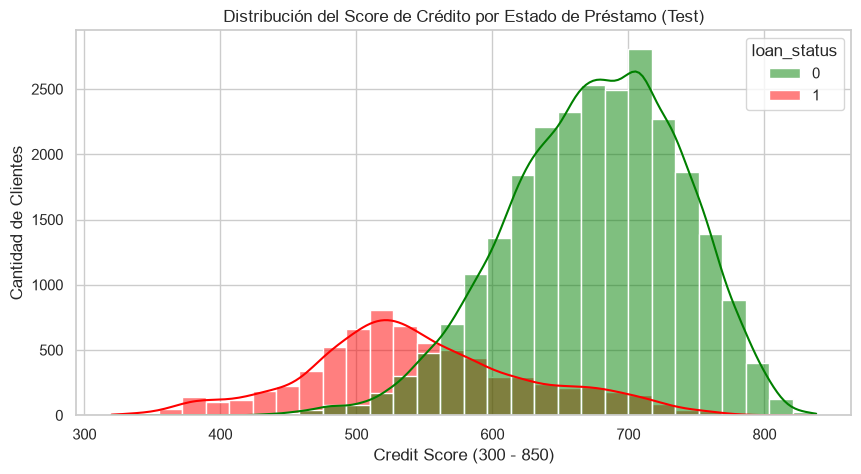

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(data=df_resultado, x='Score', hue='loan_status', bins=30, kde=True, palette={0: 'green', 1: 'red'})
plt.title('Distribución del Score de Crédito por Estado de Préstamo')
plt.xlabel('Credit Score (300 - 850)')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [25]:
import pandas as pd

# tener en cuenta: esto corre sobre df entero, o sea 70% son datos que el modelo ya vio.
# para elegir el corte en serio habria que hacerlo solo con test
thresholds = range(450, 775, 25)
estrategia = []

total_clientes = len(df_resultado)
total_defaults = df_resultado['loan_status'].sum()

for cut in thresholds:
    aprobados = df_resultado[df_resultado['Score'] >= cut]
    rechazados = df_resultado[df_resultado['Score'] < cut]
    
    num_aprobados = len(aprobados)
    pct_aprobados = (num_aprobados / total_clientes) * 100
    
    num_defaults_aprobados = aprobados['loan_status'].sum()
    bad_rate_aprobados = (num_defaults_aprobados / num_aprobados * 100) if num_aprobados > 0 else 0
    
    # morosos que me ahorro rechazando
    defaults_rechazados = rechazados['loan_status'].sum()
    bad_capture = (defaults_rechazados / total_defaults * 100)
    
    estrategia.append({
        'corte': cut,
        '% aprobados': round(pct_aprobados, 1),
        'cant_aprobados': num_aprobados,
        'bad_rate': round(bad_rate_aprobados, 2),
        'bad_capture': round(bad_capture, 1)
    })

df_estrategia = pd.DataFrame(estrategia)
df_estrategia

,corte,% aprobados,cant_aprobados,bad_rate,bad_capture
0,450,97.7,31833,20.03,10.3
1,475,96.2,31359,18.98,16.2
2,500,93.5,30467,16.96,27.3
3,525,89.6,29191,13.98,42.6
4,550,85.1,27721,11.05,56.9
5,575,80.0,26077,8.80,67.7
6,600,73.6,23992,7.02,76.3
7,625,65.2,21259,5.84,82.5
8,650,55.0,17916,5.10,87.1
9,675,43.2,14078,4.24,91.6


In [26]:
bins_score = [0, 500, 570, 640, 720, 900]
labels_riesgo = ['E (Muy Alto)', 'D (Alto)', 'C (Medio)', 'B (Bajo)', 'A (Muy Bajo)']

df_resultado['Banda_Riesgo'] = pd.cut(df_resultado['Score'], bins=bins_score, labels=labels_riesgo)

resumen_bandas = df_resultado.groupby('Banda_Riesgo', observed=False).agg(
    Cant_Clientes=('loan_status', 'count'),
    Cant_Defaults=('loan_status', 'sum'),
    Tasa_Default=('loan_status', 'mean')
).reset_index()

resumen_bandas['% del Total'] = (resumen_bandas['Cant_Clientes'] / len(df_resultado) * 100).round(1)
resumen_bandas['Tasa_Default (% Mora)'] = (resumen_bandas['Tasa_Default'] * 100).round(2)

resumen_bandas

,Banda_Riesgo,Cant_Clientes,Cant_Defaults,Tasa_Default,% del Total,Tasa_Default (% Mora)
0,E (Muy Alto),2160,1984,0.918519,6.6,91.85
1,D (Alto),4049,2713,0.670042,12.4,67.00
2,C (Medio),7186,1370,0.190648,22.1,19.06
3,B (Bajo),12497,898,0.071857,38.4,7.19
4,A (Muy Bajo),6689,143,0.021378,20.5,2.14


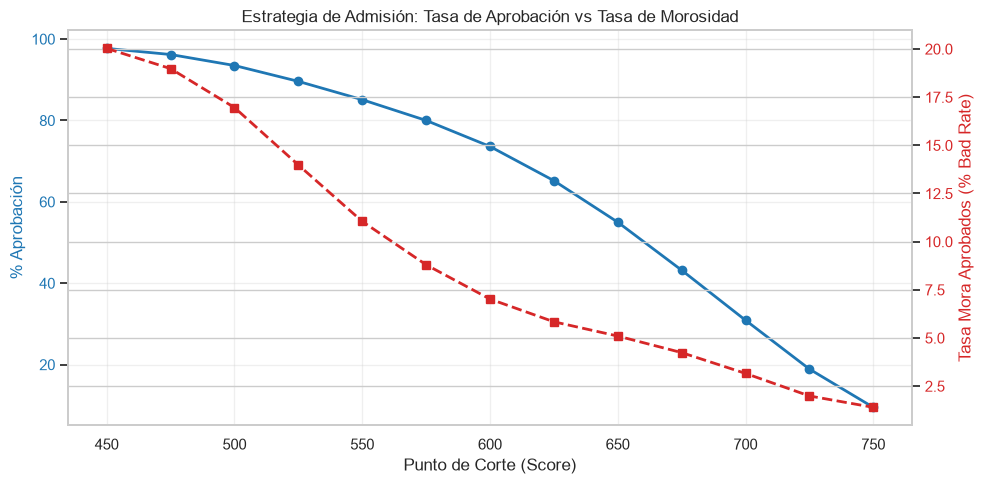

In [27]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Punto de Corte (Score)')
ax1.set_ylabel('% Aprobación', color='tab:blue')
ax1.plot(df_estrategia['corte'], df_estrategia['% aprobados'], color='tab:blue', marker='o', linewidth=2, label='% Aprobación')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  
ax2.set_ylabel('Tasa Mora Aprobados (% Bad Rate)', color='tab:red')
ax2.plot(df_estrategia['corte'], df_estrategia['bad_rate'], color='tab:red', marker='s', linestyle='--', linewidth=2, label='% Mora')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Estrategia de Admisión: Tasa de Aprobación vs Tasa de Morosidad')
fig.tight_layout()
plt.show()

In [28]:
def evaluar_solicitante(datos_cliente, scorecard, cutoff_aprobacion=600, cutoff_revision=530):
    df_cliente = pd.DataFrame([datos_cliente])
    score = int(round(scorecard.score(df_cliente)[0]))
    
    if score >= cutoff_aprobacion:
        decision = "APROBADO"
        recomendacion = "Otorgar préstamo con tasa estándar / preferencial."
    elif score >= cutoff_revision:
        decision = "REVISIÓN MANUAL"
        recomendacion = "Solicitar documentación adicional (recibo de sueldo, garantes)."
    else:
        decision = "RECHAZADO"
        recomendacion = "Rechazar solicitud. Nivel de riesgo superior al tolerado."
    
    print(f"score {score} -> {decision}")
    print(recomendacion)
    
    return {'score': score, 'decision': decision}


# testeamooo
nuevo_solicitante = {
    'person_age': 28,
    'person_income': 65000,
    'person_home_ownership': 'RENT',
    'person_emp_length': 4.0,
    'loan_intent': 'PERSONAL',
    'loan_grade': 'B',
    'loan_amnt': 8000,
    'loan_int_rate': 11.2,
    'loan_percent_income': 0.12,
    'cb_person_default_on_file': 'N',
    'cb_person_cred_hist_length': 5
}

resultado = evaluar_solicitante(nuevo_solicitante, scorecard, cutoff_aprobacion=600, cutoff_revision=530)

score 676 -> APROBADO
Otorgar préstamo con tasa estándar / preferencial.


In [29]:
scorecard_export = scorecard.table(style="summary")
scorecard_export['Points'] = scorecard_export['Points'].round(2)
scorecard_export.to_csv("outputs/Scorecard_Credito_Puntos.csv", index=False)

scorecard_export.head(15)

,Variable,Bin,Points
0,person_age,"(-inf, 22.50)",55.96
1,person_age,"[22.50, 25.50)",56.27
2,person_age,"[25.50, 28.50)",56.31
3,person_age,"[28.50, 31.50)",56.40
4,person_age,"[31.50, 34.50)",56.48
5,person_age,"[34.50, 38.50)",56.36
6,person_age,"[38.50, inf)",56.27
7,person_age,Special,56.27
8,person_age,Missing,56.27
0,person_income,"(-inf, 22840.00)",-11.70


In [30]:
import pickle

modelo_completo = {
    'binning_process': binning_process,
    'scorecard': scorecard,
    'cutoff_aprobacion': 600,
    'cutoff_revision': 570,
    'gini': gini_test,
    'ks': ks_stat * 100
}

with open("models/scorecard_model.pkl", "wb") as f:
    pickle.dump(modelo_completo, f)

print("guardado. gini", round(gini_test, 4), "ks", round(ks_stat * 100, 2))

guardado. gini 0.773 ks 64.5
